In [3]:
import geopandas as gpd
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from CEStools.utils import clean_data

We sought to reproduce the charts of 'Analysis of Race/Ethnicity and CalEnviroScreen 4.0 Scores' report. 

In [4]:
shape = gpd.read_file('data/calenviroscreen40_shp/CES4 Final Shapefile.shp')
df = clean_data(shape)

In [7]:
race_cols = ['Hispanic', 'White', 'AfricanAm', 'NativeAm', 'OtherMult', 'AAPI']
df['sum'] = df.loc[:, 'Hispanic'] + df.loc[:, 'White'] + df.loc[:, 'AfricanAm'] + df.loc[:, 'NativeAm'] + df.loc[:, 'OtherMult']+df.loc[:, 'AAPI']

df[race_cols + ['sum']].describe()

,Hispanic,White,AfricanAm,NativeAm,OtherMult,AAPI,sum
count,8011.000000,8011.000000,8011.000000,8011.000000,8011.000000,8011.000000,8011.000000
mean,38.090437,38.671210,5.566892,0.418729,3.267521,13.985211,100.000000
std,26.434934,25.957581,8.575135,2.225242,2.445139,15.655214,0.000069
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,99.999800
25%,15.671250,14.726950,0.835100,0.000000,1.393800,3.234700,100.000000
50%,30.939400,37.246200,2.565900,0.000000,2.846400,8.429500,100.000000
75%,58.169800,60.991000,6.648450,0.360400,4.703750,18.505750,100.000000
max,100.000000,100.000000,84.708200,100.000000,17.065300,94.549900,100.000200


We verified that the race/ethnicity proportions within each county sum to 100%, which supports the reliability of the dataset.

**Figure 1. CalEnviroScreen 4.0 Score by Racial or Ethnic Group**

The original report generated this figure using individual-level data, where each observation represents a single Californian. With this structure, they were able to assign each person a CalEnviroScreen 4.0 percentile score based on their census tract and then group individuals by race/ethnicity to compute the accurate score distribution for each group.

However, our dataset is at the county level. While we had the total population data, generating the long-format dataset by repeatedly appending observations was avoided due to high time consumption. Thus we approximately generated the boxplot by assigning each county to the race/ethnicity group with the highest proportion.

/var/folders/0k/jn4h9ptx7_500msv80bg_rcm0000gn/T/ipykernel_70110/2335616433.py:1: FutureWarning: The behavior of DataFrame.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  df.loc[:, 'major_race'] = df[race_cols].idxmax(axis=1)
/var/folders/0k/jn4h9ptx7_500msv80bg_rcm0000gn/T/ipykernel_70110/2335616433.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, 'major_race'] = df[race_cols].idxmax(axis=1)


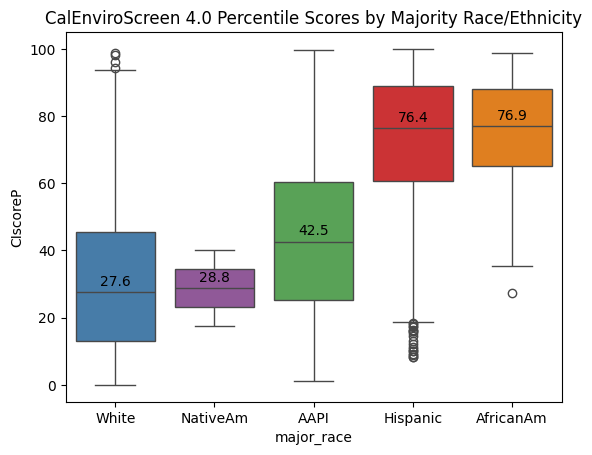

In [18]:
df.loc[:, 'major_race'] = df[race_cols].idxmax(axis=1)
median = df.groupby('major_race')['CIscoreP'].median().sort_values()
median_order = median.index
sns.boxplot(data= df, x='major_race', y='CIscoreP', order= median_order, palette="Set1", hue = 'major_race', legend=False)
plt.title('CalEnviroScreen 4.0 Percentile Scores by Majority Race/Ethnicity')
for tick, label in enumerate(median_order):
    median_value = median[label]
    plt.text(tick, median_value+2, f'{median_value:.1f}', horizontalalignment='center')

plt.savefig("visualizations/descriptive_charts/fig1_majorityrace_BaW.png", dpi=300, bbox_inches="tight")

In [19]:
df['major_race'].value_counts()

major_race
White        3853
Hispanic     3279
AAPI          763
AfricanAm     112
NativeAm        4
Name: count, dtype: int64

The comparison between the original figure 1 and the reproduced analysis confirms the severe structural environment injustice in California. The African American (corresponding to Black) and Hispanic (corresponding to Latino) groups shows the consistently highest median vulnerability score, and the White group shows the lowest. This indicates that Hispanic and African American populations tend to live in communities with higher pollution burdens and vulnerabilities than the other/racial/ethnic groups analyzed. \
\
However, the methodology used for the reproduction seemingly inflated the median scores significantly compared to the original report. Also, the extremely low count for the Native American group (n=4) makes its derived median unreliable for comparison purposes.

**Figure 2. Race in the Least and Most Impacted Census Tracts of CalEnviroScreen 4.0.**

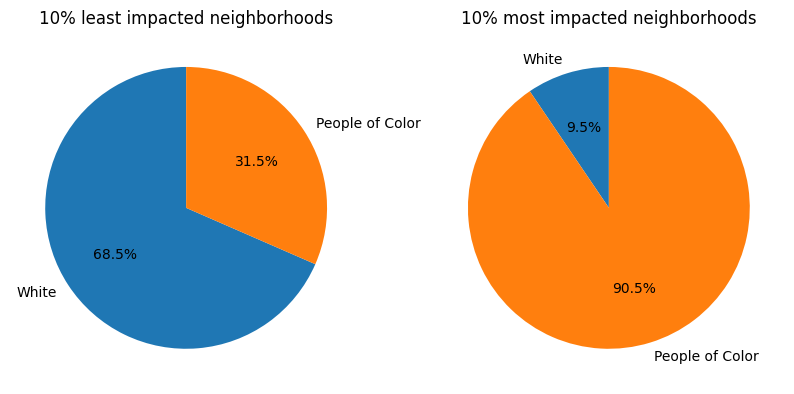

In [20]:
bottom = df[df['CIscoreP'] <= 10]
top = df[df['CIscoreP'] >= 90]

bottom_white = bottom['White'].mean()
bottom_poc = 100 - bottom_white

top_white = top['White'].mean()
top_poc = 100 - top_white

labels = ['White', 'People of Color']
bottom_sizes = [bottom_white, bottom_poc]
top_sizes = [top_white, top_poc]

fig, ax = plt.subplots(1, 2, figsize = (10, 5))
ax[0].pie(bottom_sizes, labels=labels, autopct='%1.1f%%', startangle=90)
ax[0].set_title('10% least impacted neighborhoods')
ax[1].pie(top_sizes, labels=labels, autopct='%1.1f%%', startangle=90)
ax[1].set_title('10% most impacted neighborhoods')

plt.savefig("visualizations/descriptive_charts/fig2_topbottomtracts_piechart.png", dpi=300, bbox_inches="tight")

**Figure 3. Racial Makeup of Each Decile of CalEnviroScreen 4.0 Score.**

/var/folders/0k/jn4h9ptx7_500msv80bg_rcm0000gn/T/ipykernel_70110/1498311064.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['decile'] = pd.qcut(df['CIscoreP'], 10, labels=False) + 1


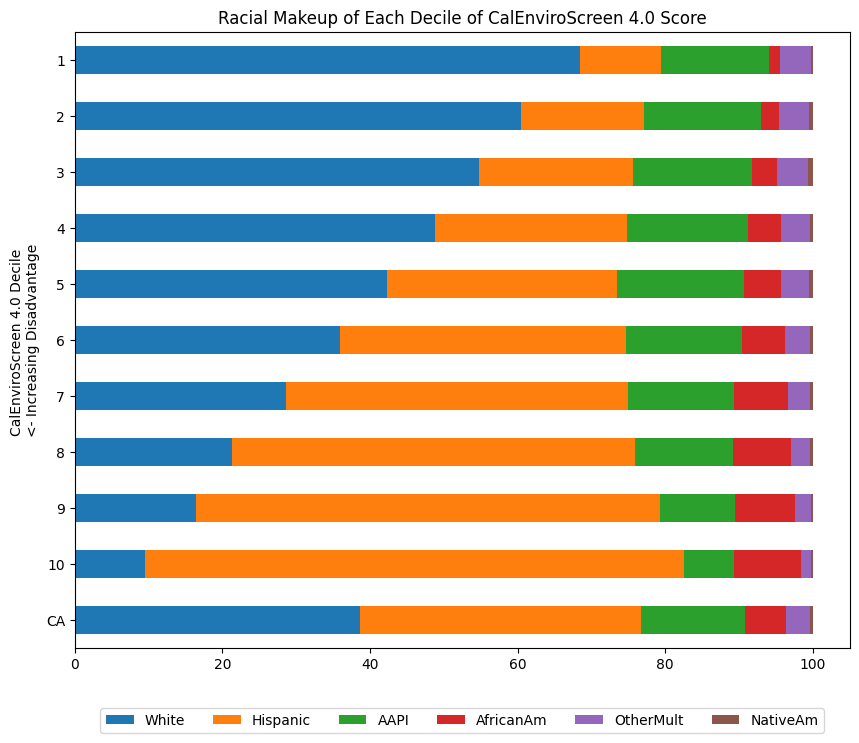

In [21]:
df['decile'] = pd.qcut(df['CIscoreP'], 10, labels=False) + 1
decile_means = df.groupby('decile')[race_cols].mean()
decile_means.index = list(range(1, 11))
ca_means = df[race_cols].mean()
ca_df = ca_means.to_frame().T
ca_df.index = ['CA']
df_plot = pd.concat([decile_means, ca_df], axis=0)

plot_order = ['White', 'Hispanic', 'AAPI', 'AfricanAm', 'OtherMult', 'NativeAm']

fig, ax = plt.subplots(figsize=(10, 8))
df_plot[plot_order].plot(kind='barh', stacked=True, ax=ax)
ax.set_ylabel('CalEnviroScreen 4.0 Decile \n<- Increasing Disadvantage')
ax.invert_yaxis()
ax.legend(loc='lower center', bbox_to_anchor = (0.5, -0.15), ncol = 6)
plt.title('Racial Makeup of Each Decile of CalEnviroScreen 4.0 Score')

plt.savefig("visualizations/descriptive_charts/fig3_racialmakeupbydecile_barchart.png", dpi=300, bbox_inches="tight")

The results are consistent with the original conclusions, reaffirming the environmental racial inequity within California.
As environmental vulnerability increases (moving to higher deciles), the proportion of Hispanic and African American residents increases overwhelmingly. Conversely, the proportion of White residents decreases sharply as the disadvantage lessens, suggesting they predominantly reside in the most environmentally safe areas. This inequality is further highlighted when compared to the average bar representing the entire state of California at the bottom.

**Figure 4. Most prevalent race by census tracts were overlaid with most disadvantaged 10%
CalEnviroScreen scores.**

In [22]:
top_counts = top['major_race'].value_counts()
total_counts = df['major_race'].value_counts()
top_counts, total_counts

(major_race
 Hispanic     745
 AfricanAm     21
 White         19
 AAPI           9
 Name: count, dtype: int64,
 major_race
 White        3853
 Hispanic     3279
 AAPI          763
 AfricanAm     112
 NativeAm        4
 Name: count, dtype: int64)

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


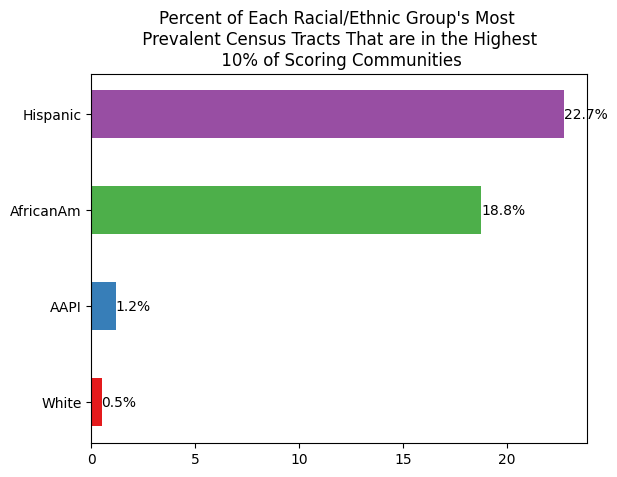

In [23]:
top_ratio = (top_counts / total_counts).sort_values(ascending=True) * 100
plt.barh(top_ratio.index, top_ratio.values, height=0.5, color=sns.color_palette("Set1"))
for i, v in enumerate(top_ratio.values):
    plt.text(v, i, f'{v:.1f}%', va='center')
plt.title("Percent of Each Racial/Ethnic Group's Most \n Prevalent Census Tracts That are in the Highest \n 10% of Scoring Communities")

plt.savefig("visualizations/descriptive_charts/fig4_top10perctracts_barchart.png", dpi=300, bbox_inches="tight")

We were able to reproduce the exact same numerical values as the original report. Although the proportion of African Americans appears 

In [27]:
def select_high_correlated_vars(df, race_cols, threshold = 0.6):
    corr = df.drop(['major_race'], axis = 1).corr()
    vars = pd.DataFrame()
    for race_col in race_cols:
        race_corr = corr[race_col].drop(race_cols)
        selected = race_corr[abs(race_corr) > threshold].sort_values(ascending=False)
        vars = pd.concat([vars, selected], axis=1)
    return vars

select_high_correlated_vars(df, race_cols)

,Hispanic,White,AfricanAm,NativeAm,OtherMult,AAPI
EducatP,0.853965,-0.775303,NaN,NaN,NaN,NaN
CIscoreP,0.741219,-0.725284,NaN,NaN,NaN,NaN
decile,0.738075,-0.720705,NaN,NaN,NaN,NaN
PopCharP,0.729622,-0.713956,NaN,NaN,NaN,NaN
PovertyP,0.675304,NaN,NaN,NaN,NaN,NaN
Ling_IsolP,0.607499,-0.753909,NaN,NaN,NaN,NaN


Excluding the CalEnviroScreen score, the correlation analysis shows that areas with a higher Hispanic population tend to have a larger proportion of residents with less than a high school education, higher poverty rates, and greater linguistic isolation, meaning more households with limited English proficiency. In contrast, areas with a higher White populations tend to have higher education levels and fewer linguistically isolated households.